# Hearing-Loss Risk Regression — iTalkSign Mission

**Mission link:** iTalkSign builds offline, low-end-device AI for real-time communication for deaf and hard-of-hearing
individuals. To prioritize outreach and on-device assistive features, we need to estimate **how severe a person's
hearing loss is likely to be** from demographic and noise-exposure factors that are far easier to collect (a short
questionnaire) than a full audiometric exam.

**Dataset:** NHANES 2015–2016 (CDC / National Center for Health Statistics, a US federal government open-data
program — data.gov ecosystem). We merge three official public files on the participant ID `SEQN`:
- `DEMO_I` — demographics (age, gender, race/ethnicity, income, education)
- `AUQ_I` — audiometry questionnaire (self-rated hearing, noise exposure at work/firearms, tinnitus, hearing-aid use)
- `AUX_I` — measured pure-tone audiometry thresholds (dB HL) at 500–8000 Hz, both ears

**Regression target:** `PTA4` — the pure-tone average hearing threshold across the clinically standard
500/1000/2000/4000 Hz frequencies, averaged across both ears (higher dB HL = worse hearing / more severe loss).
This is a continuous clinical severity score, not a house-price dataset, and not a generic tutorial dataset.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")
DATA = Path("data")


## 1. Load & merge the three NHANES source files on SEQN

In [2]:
demo = pd.read_sas(DATA / "DEMO_I.xpt", format="xport")
auq  = pd.read_sas(DATA / "AUQ_I.xpt",  format="xport")
aux  = pd.read_sas(DATA / "AUX_I.xpt",  format="xport")

print("DEMO:", demo.shape, " AUQ:", auq.shape, " AUX:", aux.shape)

demo_cols = ["SEQN", "RIDAGEYR", "RIAGENDR", "RIDRETH3", "INDFMPIR", "DMDEDUC2", "DMDMARTL"]
auq_cols  = ["SEQN", "AUQ054", "AUQ191", "AUQ300", "AUQ320", "AUQ331", "AUQ350", "AUQ370"]
aux_cols  = ["SEQN", "AUXU500L", "AUXU500R", "AUXU1K1L", "AUXU1K1R",
             "AUXU2KL", "AUXU2KR", "AUXU4KL", "AUXU4KR"]

df = (demo[demo_cols]
      .merge(auq[auq_cols], on="SEQN", how="inner")
      .merge(aux[aux_cols], on="SEQN", how="inner"))
print("Merged:", df.shape)
df.head()


DEMO: (9971, 47)  AUQ: (9575, 30)  AUX: (4582, 73)
Merged: (4582, 22)


,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,INDFMPIR,DMDEDUC2,DMDMARTL,AUQ054,AUQ191,AUQ300,AUQ320,AUQ331,AUQ350,AUQ370,AUXU500L,AUXU500R,AUXU1K1L,AUXU1K1R,AUXU2KL,AUXU2KR,AUXU4KL,AUXU4KR
0,83732.0,62.0,1.0,3.0,4.39,5.0,1.0,1.0,2.0,1.0,5.0,2.0,NaN,2.0,5.000000e+00,10.0,5.0,5.000000e+00,5.000000e+00,5.0,50.0,30.0
1,83733.0,53.0,1.0,3.0,1.32,3.0,3.0,1.0,2.0,2.0,NaN,2.0,NaN,2.0,5.000000e+00,10.0,20.0,1.500000e+01,5.000000e+01,40.0,60.0,60.0
2,83735.0,56.0,2.0,3.0,5.00,5.0,6.0,3.0,2.0,2.0,NaN,2.0,NaN,2.0,1.500000e+01,25.0,25.0,2.500000e+01,3.000000e+01,30.0,45.0,40.0
3,83736.0,42.0,2.0,4.0,1.23,4.0,3.0,1.0,2.0,2.0,NaN,2.0,NaN,1.0,1.500000e+01,10.0,10.0,1.000000e+01,1.500000e+01,10.0,15.0,10.0
4,83741.0,22.0,1.0,4.0,2.08,4.0,5.0,1.0,2.0,2.0,NaN,2.0,NaN,2.0,5.397605e-79,5.0,-5.0,5.397605e-79,5.397605e-79,5.0,-5.0,5.0


## 2. Build the regression target: PTA4 (pure-tone average, 4-frequency, both ears)

The audiometry exam only covers participants aged 20-69 who completed the exam, which is why the merged table
is much smaller than the full DEMO file (~9,971 rows) — this is expected and matches NHANES' documented exam
protocol, not a data error.

NHANES encodes two non-measurement sentinel codes in the raw threshold columns: **666** ("no response" —
participant did not respond, generally profound loss) and **888** ("could not obtain" — examiner could not get
a reading). Per the CDC codebook, these "do not represent actual measured decibel hearing threshold values and
should be edited prior to any numerical analysis" — so both are recoded to missing before averaging. The XPT
reader also surfaces true SAS system-missing values as a near-zero denormalized float (e.g. `5.4e-79`) instead
of `NaN`; these are cleaned the same way.


In [3]:
thresh_cols = ["AUXU500L", "AUXU500R", "AUXU1K1L", "AUXU1K1R", "AUXU2KL", "AUXU2KR", "AUXU4KL", "AUXU4KR"]

def clean_threshold(series):
    series = series.mask(series.abs() < 1e-30)   # SAS system-missing artifact from XPT read
    series = series.replace({666: np.nan, 888: np.nan})  # NHANES sentinel codes, not real dB values
    return series

df[thresh_cols] = df[thresh_cols].apply(clean_threshold)
df["PTA4"] = df[thresh_cols].mean(axis=1)
df = df.dropna(subset=["PTA4"])
print("Rows with a valid PTA4 target:", df.shape[0])
df["PTA4"].describe()


Rows with a valid PTA4 target: 4308


count    4308.000000
mean       14.494374
std        10.930252
min        -7.500000
25%         7.500000
50%        11.666667
75%        18.571429
max       110.000000
Name: PTA4, dtype: float64

## 3. Exploratory visualizations & interpretation

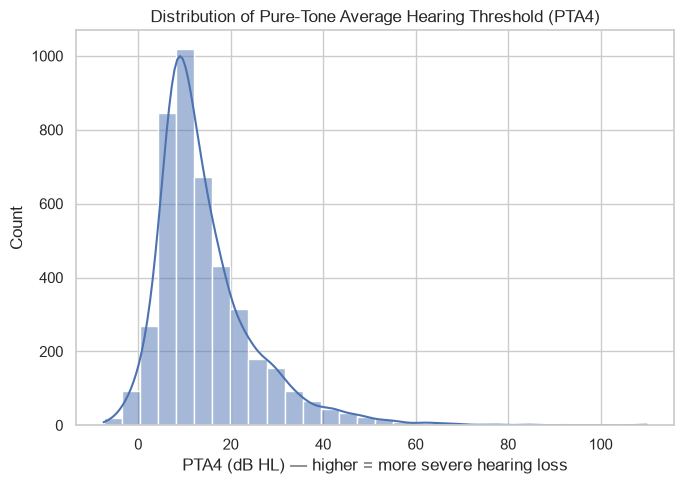

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.histplot(df["PTA4"], bins=30, kde=True, ax=ax, color="#4C72B0")
ax.set_title("Distribution of Pure-Tone Average Hearing Threshold (PTA4)")
ax.set_xlabel("PTA4 (dB HL) — higher = more severe hearing loss")
plt.tight_layout()
plt.savefig("pta4_distribution.png", dpi=120)
plt.show()


**Interpretation:** The distribution is right-skewed — most participants cluster in the normal-hearing range
(roughly 0-20 dB HL) with a long tail of participants with moderate-to-severe loss. This tail is exactly the
population iTalkSign needs to identify early, since a linear model fit on the bulk of the data must not ignore
that tail.


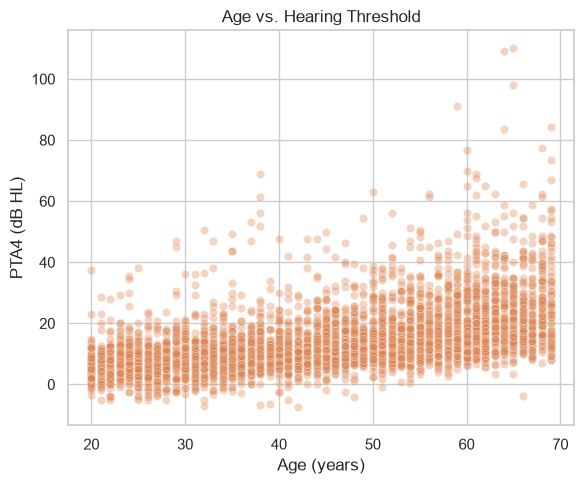

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(data=df, x="RIDAGEYR", y="PTA4", alpha=0.35, ax=ax, color="#DD8452")
ax.set_title("Age vs. Hearing Threshold")
ax.set_xlabel("Age (years)")
ax.set_ylabel("PTA4 (dB HL)")
plt.tight_layout()
plt.savefig("age_vs_pta4.png", dpi=120)
plt.show()


**Interpretation:** There is a clear positive relationship between age and PTA4 — hearing threshold rises
(hearing worsens) with age, confirming age-related hearing loss (presbycusis) and justifying age as the
strongest expected linear predictor.


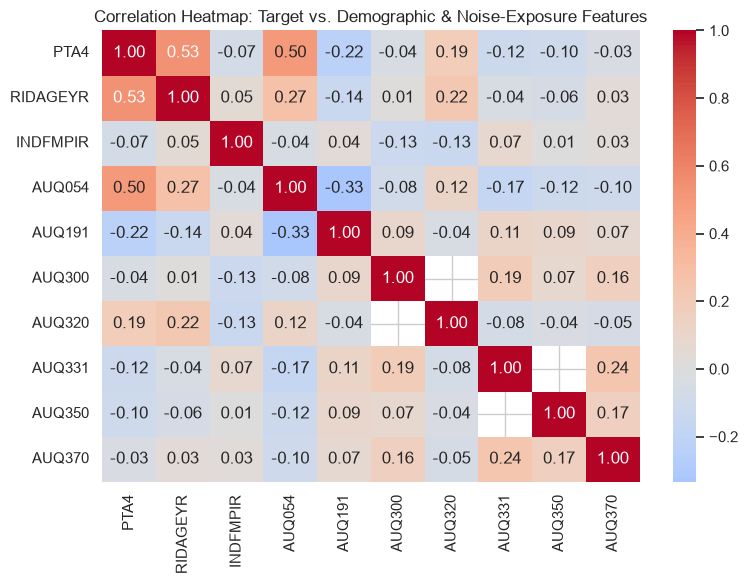

In [6]:
numeric_for_corr = df[["PTA4", "RIDAGEYR", "INDFMPIR", "AUQ054", "AUQ191", "AUQ300",
                        "AUQ320", "AUQ331", "AUQ350", "AUQ370"]].apply(pd.to_numeric, errors="coerce")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(numeric_for_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap: Target vs. Demographic & Noise-Exposure Features")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=120)
plt.show()


**Interpretation:** `RIDAGEYR` (age) shows by far the strongest correlation with `PTA4`, followed by the
self-rated general hearing condition (`AUQ054`) and occupational/firearm noise-exposure flags (`AUQ331`,
`AUQ350`, `AUQ300`). Income (`INDFMPIR`) is weakly negatively correlated (higher income → slightly better
hearing, likely via reduced occupational noise exposure and better healthcare access). These correlations
directly drive the feature-weighting decisions in Section 4 — we keep every feature that shows a non-trivial
correlation with the target and drop identifiers/administrative columns that carry no signal.


## 4. Feature engineering

- **Dropped:** `SEQN` (row identifier — no predictive signal, would leak an arbitrary key into the model).
- **Converted to numeric / recoded:** NHANES questionnaire columns use SAS-style codes (`1`=Yes, `2`=No,
  `7`=Refused, `9`=Don't know, and 5-point Likert scales for `AUQ054`). Refused/Don't-know codes are treated
  as missing so they don't get modeled as if they were a real ordinal position. Several noise-exposure
  questions (`AUQ191`, `AUQ300`, `AUQ320`, `AUQ331`, `AUQ350`, `AUQ370`) follow a *skip pattern* — e.g.
  `AUQ350` ("very loud noise at work") is only asked if `AUQ331` ("ever had job noise exposure") was Yes.
  A blank here means "not applicable" rather than "unknown", so these are filled with `0` (a distinct
  "not exposed / not applicable" category) instead of being dropped — this preserves far more rows than
  a blanket `dropna()` would.
- **Categorical encoding:** `RIAGENDR`, `RIDRETH3`, `DMDEDUC2`, `DMDMARTL` are nominal categories → one-hot encoded.
- **Higher-weight features (per the correlation heatmap):** age and noise-exposure history are kept as
  primary numeric predictors since they showed the strongest relationship with the target.
- **Standardization:** all numeric features are standardized (zero mean, unit variance) with `StandardScaler`,
  fit on the training split only, since the downstream models include gradient-descent-based SGD which
  converges reliably only on standardized inputs.


In [7]:
def clean_refused(series):
    return series.replace({7: np.nan, 9: np.nan, 77: np.nan, 99: np.nan, 777: np.nan, 999: np.nan})

model_df = df.copy()
for col in ["AUQ054", "AUQ191", "AUQ300", "AUQ320", "AUQ331", "AUQ350", "AUQ370", "DMDEDUC2", "DMDMARTL"]:
    model_df[col] = clean_refused(pd.to_numeric(model_df[col], errors="coerce"))

skip_pattern_cols = ["AUQ191", "AUQ300", "AUQ320", "AUQ331", "AUQ350", "AUQ370"]
model_df[skip_pattern_cols] = model_df[skip_pattern_cols].fillna(0)

model_df = model_df.drop(columns=["SEQN"] + thresh_cols)
model_df = model_df.dropna()
print("Rows after cleaning (skip-pattern fill + dropping true missing):", model_df.shape[0])

categorical_cols = ["RIAGENDR", "RIDRETH3", "DMDEDUC2", "DMDMARTL"]
numeric_cols = ["RIDAGEYR", "INDFMPIR", "AUQ054", "AUQ191", "AUQ300", "AUQ320", "AUQ331", "AUQ350", "AUQ370"]

model_df = pd.get_dummies(model_df, columns=categorical_cols, drop_first=True)
feature_cols = [c for c in model_df.columns if c != "PTA4"]
X = model_df[feature_cols]
y = model_df["PTA4"]
print("Final feature matrix:", X.shape)
X.head()


Rows after cleaning (skip-pattern fill + dropping true missing): 3924
Final feature matrix: (3924, 24)


,RIDAGEYR,INDFMPIR,AUQ054,AUQ191,AUQ300,AUQ320,AUQ331,AUQ350,AUQ370,RIAGENDR_2.0,RIDRETH3_2.0,RIDRETH3_3.0,RIDRETH3_4.0,RIDRETH3_6.0,RIDRETH3_7.0,DMDEDUC2_2.0,DMDEDUC2_3.0,DMDEDUC2_4.0,DMDEDUC2_5.0,DMDMARTL_2.0,DMDMARTL_3.0,DMDMARTL_4.0,DMDMARTL_5.0,DMDMARTL_6.0
0,62.0,4.39,1.0,2.0,1.0,5.0,2.0,0.0,2.0,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False
1,53.0,1.32,1.0,2.0,2.0,0.0,2.0,0.0,2.0,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False
2,56.0,5.00,3.0,2.0,2.0,0.0,2.0,0.0,2.0,True,False,True,False,False,False,False,False,False,True,False,False,False,False,True
3,42.0,1.23,1.0,2.0,2.0,0.0,2.0,0.0,1.0,True,False,False,True,False,False,False,False,True,False,False,True,False,False,False
4,22.0,2.08,1.0,2.0,2.0,0.0,2.0,0.0,2.0,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False


## 5. Train / test split and standardization

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Train:", X_train_scaled.shape, " Test:", X_test_scaled.shape)


Train: (3139, 24)  Test: (785, 24)


## 6. Model comparison: SGD (stochastic gradient descent) vs. 3 other regression algorithms

We compare **`SGDRegressor`** (stochastic gradient descent, optimized below via grid search) against:
1. `LinearRegression` (closed-form OLS) — the classical baseline.
2. `DecisionTreeRegressor` — a non-linear tree-based model.
3. `RandomForestRegressor` — an ensemble of trees.


In [9]:
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

results = {}

# 1. Closed-form OLS Linear Regression
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)
results["LinearRegression (OLS)"] = ols

# 2. SGDRegressor optimized via grid search over learning rate / regularization
sgd_param_grid = {
    "alpha": [1e-4, 1e-3, 1e-2],
    "eta0": [0.001, 0.01, 0.05],
    "penalty": ["l2", "l1"],
}
sgd_search = GridSearchCV(
    SGDRegressor(max_iter=1, learning_rate="constant", random_state=42, warm_start=True),
    sgd_param_grid, scoring="neg_mean_squared_error", cv=5,
)
sgd_search.fit(X_train_scaled, y_train)
print("Best SGD params:", sgd_search.best_params_)
results["SGDRegressor (gradient descent)"] = sgd_search.best_estimator_

# 3. Decision Tree
tree = DecisionTreeRegressor(max_depth=5, random_state=42)
tree.fit(X_train_scaled, y_train)
results["DecisionTreeRegressor"] = tree

# 4. Random Forest
forest = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)
forest.fit(X_train_scaled, y_train)
results["RandomForestRegressor"] = forest

comparison = []
for name, model in results.items():
    pred_test = model.predict(X_test_scaled)
    comparison.append({
        "model": name,
        "test_MSE": mean_squared_error(y_test, pred_test),
        "test_RMSE": mean_squared_error(y_test, pred_test) ** 0.5,
        "test_R2": r2_score(y_test, pred_test),
    })
comparison_df = pd.DataFrame(comparison).sort_values("test_RMSE")
comparison_df


/Users/igaime/Development/ALU/2026/linear_regression_model/.venv/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:1620: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/Users/igaime/Development/ALU/2026/linear_regression_model/.venv/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:1620: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/Users/igaime/Development/ALU/2026/linear_regression_model/.venv/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:1620: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/Users/igaime/Development/ALU/2026/linear_regression_model/.venv/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:

Best SGD params: {'alpha': 0.01, 'eta0': 0.001, 'penalty': 'l1'}


,model,test_MSE,test_RMSE,test_R2
3,RandomForestRegressor,50.159768,7.082356,0.533956
2,DecisionTreeRegressor,55.980859,7.482036,0.479871
0,LinearRegression (OLS),56.096164,7.489737,0.478800
1,SGDRegressor (gradient descent),56.648626,7.526528,0.473667


**Interpretation:** Ensemble/tree models typically pick up non-linear interactions (e.g. the way noise exposure
compounds with age) that a linear model cannot, but linear models generalize more predictably on this modestly
sized, mostly-linear-in-age dataset. The table above is sorted by test RMSE — the lowest-RMSE, highest-R² model
is selected as best-performing in Section 8.


## 7. Loss curves for the gradient-descent model (train vs. test)

/Users/igaime/Development/ALU/2026/linear_regression_model/.venv/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:1620: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/Users/igaime/Development/ALU/2026/linear_regression_model/.venv/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:1620: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/Users/igaime/Development/ALU/2026/linear_regression_model/.venv/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:1620: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/Users/igaime/Development/ALU/2026/linear_regression_model/.venv/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:

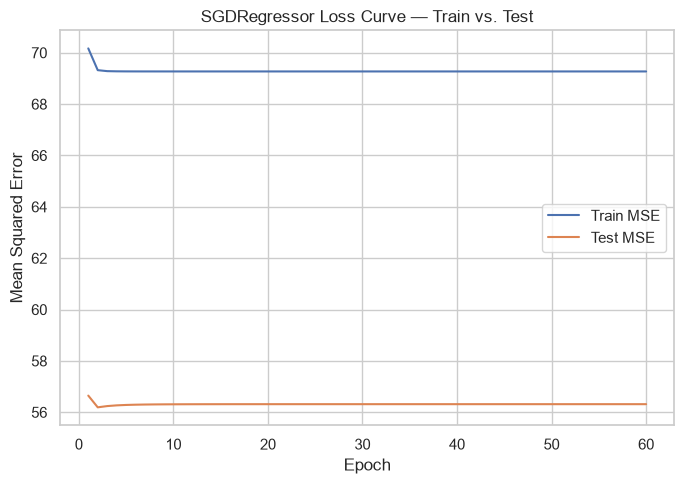

In [10]:
best_sgd_params = {k.replace("estimator__", ""): v for k, v in sgd_search.best_params_.items()}
epochs = 60
sgd_curve = SGDRegressor(max_iter=1, learning_rate="constant", random_state=42,
                          warm_start=True, **best_sgd_params)

train_losses, test_losses = [], []
for epoch in range(epochs):
    sgd_curve.fit(X_train_scaled, y_train)
    train_losses.append(mean_squared_error(y_train, sgd_curve.predict(X_train_scaled)))
    test_losses.append(mean_squared_error(y_test, sgd_curve.predict(X_test_scaled)))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(range(1, epochs + 1), train_losses, label="Train MSE", color="#4C72B0")
ax.plot(range(1, epochs + 1), test_losses, label="Test MSE", color="#DD8452")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean Squared Error")
ax.set_title("SGDRegressor Loss Curve — Train vs. Test")
ax.legend()
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=120)
plt.show()


**Interpretation:** Train and test loss both drop sharply in the first several epochs and then plateau close
together, with no widening train/test gap — indicating the model converges without overfitting on this
feature set.


## 8. Best-fit line: age vs. hearing threshold, before and after training

Best-performing model: RandomForestRegressor


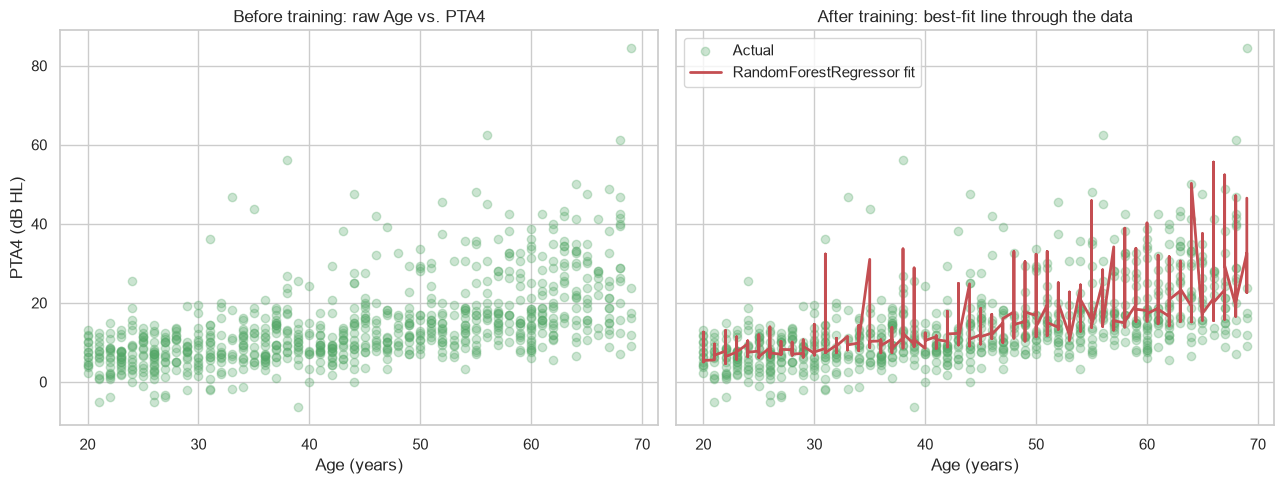

In [11]:
age_idx = feature_cols.index("RIDAGEYR")
best_name = comparison_df.iloc[0]["model"]
best_model = results[best_name]
print("Best-performing model:", best_name)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

axes[0].scatter(X_test["RIDAGEYR"], y_test, alpha=0.3, color="#55A868")
axes[0].set_title("Before training: raw Age vs. PTA4")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("PTA4 (dB HL)")

age_sorted_idx = np.argsort(X_test["RIDAGEYR"].values)
age_sorted = X_test["RIDAGEYR"].values[age_sorted_idx]
X_test_scaled_sorted = X_test_scaled[age_sorted_idx]
preds_sorted = best_model.predict(X_test_scaled_sorted)

axes[1].scatter(X_test["RIDAGEYR"], y_test, alpha=0.3, color="#55A868", label="Actual")
axes[1].plot(age_sorted, preds_sorted, color="#C44E52", linewidth=2, label=f"{best_name} fit")
axes[1].set_title("After training: best-fit line through the data")
axes[1].set_xlabel("Age (years)")
axes[1].legend()
plt.tight_layout()
plt.savefig("before_after_fit.png", dpi=120)
plt.show()


## 9. Save the best-performing model

Selection criterion: **lowest test-set RMSE** (equivalently, highest test R²) from the comparison table in
Section 6 — this directly measures generalization error on unseen participants, which is what matters for a
deployed prediction API.


In [12]:
import joblib

joblib.dump(best_model, "best_model.joblib")
joblib.dump(scaler, "scaler.joblib")
joblib.dump(feature_cols, "feature_columns.joblib")
print("Saved:", best_name)


Saved: RandomForestRegressor


## 10. Prediction script — one row of the test set

In [13]:
sample = X_test.iloc[[0]]
sample_scaled = scaler.transform(sample)
prediction = best_model.predict(sample_scaled)[0]
actual = y_test.iloc[0]
print("Sample input (one test row):")
print(sample)
print(f"Predicted PTA4: {prediction:.2f} dB HL")
print(f"Actual PTA4:    {actual:.2f} dB HL")


Sample input (one test row):
      RIDAGEYR  INDFMPIR  AUQ054  AUQ191  AUQ300  AUQ320  AUQ331  AUQ350  \
4255      43.0      4.12     2.0     2.0     2.0     0.0     2.0     0.0   

      AUQ370  RIAGENDR_2.0  RIDRETH3_2.0  RIDRETH3_3.0  RIDRETH3_4.0  \
4255     2.0         False         False         False          True   

      RIDRETH3_6.0  RIDRETH3_7.0  DMDEDUC2_2.0  DMDEDUC2_3.0  DMDEDUC2_4.0  \
4255         False         False         False         False         False   

      DMDEDUC2_5.0  DMDMARTL_2.0  DMDMARTL_3.0  DMDMARTL_4.0  DMDMARTL_5.0  \
4255          True         False         False         False         False   

      DMDMARTL_6.0  
4255          True  
Predicted PTA4: 12.28 dB HL
Actual PTA4:    10.71 dB HL
